In [41]:
import os
import json
import random
import string
from typing import Annotated, TypedDict, List, Sequence, Optional, Dict
from operator import add
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage,ToolMessage
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, InjectedState, tools_condition
from dotenv import load_dotenv
from rich import print as rprint

In [42]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [43]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [44]:
def merge_dicts(left:dict, right:dict)->dict:

    if not right: return left
    if not left: return right

    def is_empty(v):
        return v is None or str(v).strip().lower() in ("none","null","")

    return {**left, **{k:v for k,v in right.items() if not is_empty(v)}}

class SupervisorState(MessagesState):
    """
        State for multi-agent system
    """   
    user_input: str
    user_intent: str

    actions_taken: str
    observations: Annotated[list, add]
    response: Annotated[list, add]
    
    complaint_data: Annotated[dict, merge_dicts]
    missing_info: list
    next: str
    customer_profile: Dict
    

In [45]:
# Supervisor Node
def supervisor_node(state:SupervisorState)->SupervisorState:

 
    history = state.get("observations", [])
    user_input = state.get("user_input")
    current_intent = state.get("user_intent", "unknown")

 
    system_prompt = f"""
    You are an intent classifier.
    
    PREVIOUS CONTEXT: {history[-3:]} # Look at last 3 interactions for speed
    CURRENT INTENT: {current_intent}

    Classify the new user message: "{user_input}"
    
    INTENTS: [inquiry, complaint, churn, unknown]

    GUIDELINES:
    - If the user is answering a question you just asked, KEEP the current intent.
    - Only change the intent if the user clearly switches topics.
    - Return ONLY the label.

    Examples:
    "hello" (with no history) → unknown
    "I don't know" (after being asked about a laptop) → complaint
    "this is bad" → unknown
    "my order is damaged" → complaint
    "I want to cancel my subscription" → churn
    "What is the price?" → inquiry
    """
    # - If the user says something like "yes", "no", or "I don't know", it is NOT 'unknown'; it belongs to the CURRENT INTENT.
    res = llm.invoke([
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["user_input"]}
        ])
    
    intent=res.content.strip().lower()
    
    print("User Intent is ------> ", intent)
    
    return Command(goto="decision_node", update={
        "user_intent":intent,
    })


In [46]:
@tool
def respond_greeting(user_input:str)->dict:

    """Greets the user warmly and sets the empathetic tone for the interaction."""
    
    prompt = f"""
    You are a helpful and empathetic Customer Success Assistant.
    Greet the user warmly based on their input: "{user_input}".
    """
    res = llm.invoke([SystemMessage(content=prompt)])
    
    return res.content

In [47]:
def supervisor_node(state:SupervisorState)->SupervisorState:

    user_input = state.get("user_input",[])
    prompt="""Classify intent in Probability in four categories
    inquiry, dissatisfaction, complaint, unknown. Assign probablities to each when classfifying.
    """

    res = llm.invoke([SystemMessage(prompt)]+[HumanMessage(user_input)]).content

    return res

user_input={"user_input":"my order is delayed."}

In [48]:
res = supervisor_node(user_input)

rprint(res)

Based on the input "my order is delayed," I would classify the intent into the following categories with 
corresponding probabilities:

1. **Inquiry** (0.6) - The user is likely seeking information or clarification about the delay. They might ask 
questions like "What's causing the delay?" or "When can I expect delivery?"
2. **Dissatisfaction** (0.3) - The user is likely feeling frustrated or unhappy about the delay. They might express
disappointment or annoyance, but not necessarily escalate the issue.
3. **Complaint** (0.1) - The user is likely feeling strongly dissatisfied and wants to report or escalate the 
issue. They might demand a solution or compensation.
4. **Unknown** (0.0) - It's unlikely that the user has no intent or is simply making a statement without any 
underlying concern or question.

Please note that these probabilities are subjective and based on my understanding of the input. In reality, the 
actual intent might vary depending on the user's tone, context, and history.

In [49]:
# Worker nodes
def rag_node(state:SupervisorState)->SupervisorState:
    "Answers general user inquiries that fall outside the automated support ticket workflow."
    user_input=state.get("user_input",[])

    system_prompt="""
        You are a helpful support assistant. Provide clear, concise answers to the user's questions.
        """
    res = llm.invoke([SystemMessage(system_prompt)]+[HumanMessage(user_input)])
    
    return {'messages':res.content}

In [50]:
def build_inquiry_node():
    graph = StateGraph(SupervisorState)
    
    graph.add_node("inquiry", rag_node)

    graph.add_edge(START, "inquiry")
    graph.add_edge("inquiry", END)

    memory = MemorySaver()
    return graph.compile(checkpointer=memory)

inquiry_graph = build_inquiry_node()

def inquiry_node(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}} 
    return inquiry_graph.invoke(state, config=config)

In [51]:
user_input = {"user_input":"I need to know where is toothpaste."}

inquiry_node(user_input)

{'messages': [HumanMessage(content="The location of toothpaste can vary depending on the context, but here are a few common places you might find it:\n\n1. In your home: In a bathroom cabinet or on a bathroom counter, often next to the toothbrushes.\n2. In a hotel room: In the bathroom, usually in a cabinet or on a counter.\n3. In a public restroom: In a dispenser or on a shelf in the bathroom.\n\nIf you're looking for toothpaste in a specific building or room, I'd be happy to try and help you figure out where it might be. Can you give me a bit more context or information about your situation?", additional_kwargs={}, response_metadata={}, id='1e081ae5-3147-4925-a214-4f6fee195164')],
 'user_input': 'I need to know where is toothpaste.',
 'observations': [],
 'response': [],
 'complaint_data': {}}

In [52]:
def extract_info_node(state:SupervisorState)->SupervisorState:
    """ 
    Extracts product, issue, and date from input into JSON.
    """
    user_input = state.get("user_input",[])

    system_prompt=f""" You are an entity extractor. 
    Your goal is to extract the product information, issue_type, and purchase_date 
    from the user's input.
    - product
    - issue_type
    - purchase_date

    Respond ONLY with a valid JSON object in this exact format:
    {{
        "product": string or null,
        "issue_type": string or null,
        "purchase_date": MM/DD/YY or null
    }}
    """
     
    res = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_input)
        ])
    
    complaint_data = json.loads(res.content)
     
    return {"complaint_data":complaint_data}

def create_ticket_node(state:SupervisorState)->SupervisorState:
    """
    Finalizes the complaint by validating entity specificity and generating a user confirmation number.
    """
    complaint_data = state.get("complaint_data",[])
    
    prefix = ''.join(random.choices(string.ascii_uppercase,k=2))
    number1 = random.randint(100,1000)
    mid = ''.join(random.choices(string.ascii_uppercase))
    number2 = random.randint(10,100)
    ticket_id = f"{prefix}{number1}{mid}{number2}"

    ticket={
        "ticket_id":ticket_id,
        "status":"created",
        "details":complaint_data
    }
    return {"messages":f"Ticket {ticket['ticket_id']} has been created."}

def ask_missing_node(state:SupervisorState)->SupervisorState:
    """ 
    Prompts the user for specific missing details to complete the support ticket data.
    """
    
    complaint = state.get("complaint_data", {})
    missing_info = state.get("missing_info",{})
    prompt = f"The user provided: {complaint}. Politely ask for the following missing information {missing_info}."
    response = llm.invoke(prompt)

    return {"messages": [response.content],
            "missing_fields": []}
  

In [53]:
def router(state:SupervisorState)->SupervisorState:
    
    complaint_data=state.get("complaint_data",[])
    required_fields=["product", "issue_type", "purchase_date"]
    missing = [field for field in required_fields if not complaint_data.get(field)]

    if missing:
            return Command(
                goto="ask_missing_node", 
                update={
                    "missing_info": missing,
                    "complaint_data":complaint_data
                    } 
                )
    return Command(goto="create_ticket_node")
    

In [54]:
def build_complaint_graph():
    
    complaint_graph = StateGraph(SupervisorState)
    #Add Nodes
    complaint_graph.add_node('extract_info_node', extract_info_node)
    complaint_graph.add_node("ask_missing_node", ask_missing_node)
    complaint_graph.add_node("create_ticket_node",create_ticket_node)
    complaint_graph.add_node("router", router)

    #Add Edges
    complaint_graph.add_edge(START,'extract_info_node')
    complaint_graph.add_edge("extract_info_node","router")
    complaint_graph.add_edge("ask_missing_node",END)
    complaint_graph.add_edge("create_ticket_node",END)
    memory = MemorySaver()
    return complaint_graph.compile(checkpointer=memory)

complaint_graph = build_complaint_graph()

def complaint_node(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}}
    return complaint_graph.invoke(state, config=config)


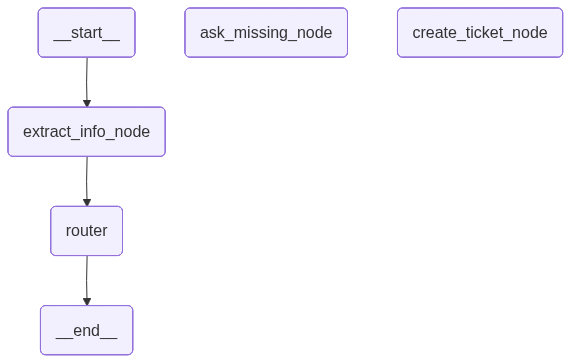

In [55]:
complaint_graph

In [56]:
usr_state = { 
    "user_input": "Oct 2, 2025."
}

In [57]:
complaint_node(usr_state)

{'messages': [HumanMessage(content='Here\'s a polite message asking the user to provide the missing information:\n\n"Hello! Thank you for providing the purchase date. However, to better assist you, we need some additional information. \n\nCould you please tell us the name of the product you purchased, and the type of issue you\'re experiencing with it? You can share this with us by updating the \'product\' and \'issue_type\' fields accordingly.\n\nPlease provide the following information:\n\n- Product name\n- Issue type\n\nOnce we have this information, we\'ll be happy to help you further."', additional_kwargs={}, response_metadata={}, id='00820509-7b81-4635-a775-0855c3f5ba9e')],
 'user_input': 'Oct 2, 2025.',
 'observations': [],
 'response': [],
 'complaint_data': {'product': None,
  'issue_type': None,
  'purchase_date': '10/02/25'},
 'missing_info': ['product', 'issue_type']}

In [58]:
def churn_score_node(state:SupervisorState)->SupervisorState:
    """
        Calculate a churn risk score from user input.
        Returns category: high, medium, or low.
    """
    user_input=state['user_input']
    current_profile = state.get('customer_profile',{})
    system_prompt = """ 
    You are a churn detection assistant.
    Based on the user input, classifiy their churn risk into:
    - high: user explicitly wants to cancel, switch, or sounds very frustrated.
    - medium: user shows dissatisfaction but hasn't decided to cancel yet.
    - low: user just asking questions or mild complaints.

    Examples:
    User: "I'm cancelling this useless service today."
    Churn risk: high

    User: "Your prices keep going up, I don't know if it's worth it anymore."
    Churn risk: medium

    User: "How do I cancel if I ever need to in the future?"
    Churn risk: low

    Respond with only one of: high, medium, low.
    """
    score = llm.invoke([
        {'role':'system', 'content':system_prompt},
        {'role':'user', 'content':user_input}
    ]).content
    
    current_profile['churn_score']=score
    return {"customer_profile":current_profile}

def loyalty_score_node(state:SupervisorState)->SupervisorState:
    """ 
        Provide loyalty score to user based on churn score and customer value. 
    """
    score = state['customer_profile']['churn_score']
    current_profile = state.get('customer_profile')
    reward_weights = {'high': 1.0, "medium": 0.6, "low": 0.2}
    clv_values = {"high": 1000, "medium": 500, "low": 200}
    clv_tier=random.choices(
        ['high','medium','low'],
        weights=[0.25,0.45,0.3],
        k=1
        )[0]

    loyalty_score = reward_weights[score]*clv_values[clv_tier]
    current_profile['loyalty_score']=loyalty_score
    current_profile['clv_tier']=clv_tier

    return {'customer_profile':current_profile}

def reward_node(state:SupervisorState)->SupervisorState:
    """
    Generate a personalized reward offers.
    """

    user_input=state['user_input']
    churn_score=state['customer_profile']['churn_score']
    loyalty_score=state['customer_profile']['loyalty_score']

    system_prompt=""" 
    You are a customer retention assistant. 
    Generate a polite, empathetic message based on the following:
    - The user's message
    - Their churn risk (high, medium, low)
    - Their loyalty score (40-1000)

    Rules:
    - If loyalty score >= 800 → emphasize strong appreciation and give a high reward (e.g., big discount, free premium month).
    - If 500-799 → show gratitude and offer a medium reward (e.g., discount or perk).
    - If 200-499 → acknowledge their value and give a small reward (e.g., loyalty points or small discount).
    - If < 200 → do not give a reward, just apologize and promise to improve.
    - If churn risk = high → always start by apologizing and showing empathy before mentioning any reward.
    - Keep the message short, friendly, concise and natural. Do not include technical terms or scores.
    
    Respond with only the final concise message.
    """

    user_context = f"""
        User message: {user_input}
        Churn risk: {churn_score}
        Loyalty score: {loyalty_score}
        """

    response = llm.invoke([{'role':'system', 'content':system_prompt},
                           {'role':'user','content':user_context}])
    
    return {"messages":response.content}


In [59]:
def build_retention_graph():

    graph = StateGraph(SupervisorState)

    graph.add_node("churn_score",churn_score_node)
    graph.add_node("evaluate_user_value",loyalty_score_node)
    graph.add_node("offer_reward",reward_node)

    graph.add_edge(START, "churn_score")
    graph.add_edge("churn_score", "evaluate_user_value")
    graph.add_edge("evaluate_user_value", "offer_reward")
    graph.add_edge("offer_reward", END)
    memory=MemorySaver()
    return graph.compile(checkpointer=memory)

In [60]:
retention_graph = build_retention_graph()

def retention_node(state:SupervisorState)->SupervisorState:
    config= {"configurable":{"thread_id":"user_complaint_session", "recursion_limit":5}}
    return retention_graph.invoke(state, config=config)

In [61]:
usr_input={"user_input":"I have problem with this phone. and you are the worst."}

In [62]:
retention_node(usr_input)

{'messages': [HumanMessage(content='"I\'m so sorry to hear you\'re having trouble with your phone. That\'s really frustrating for you. I\'m here to help and make things right. Let\'s work together to resolve the issue. As a valued customer, I\'d like to offer you 20% off your next purchase as a gesture of goodwill. How can I assist you today?"', additional_kwargs={}, response_metadata={}, id='5d1957be-87f1-4112-af04-9a0192cecb2c')],
 'user_input': 'I have problem with this phone. and you are the worst.',
 'observations': [],
 'response': [],
 'complaint_data': {},
 'customer_profile': {'churn_score': 'medium',
  'loyalty_score': 120.0,
  'clv_tier': 'low'}}

In [87]:
import torch
from transformers import pipeline
dialogue_classifier = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-small"  # fast, accurate, ~180MB
)

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [92]:
DIALOGUE_LABELS = [
    "customer reporting something is broken, not working, or malfunctioning",
    "customer asking a question to get information or learn how to do something",
    "customer expressing unhappiness or requesting action like return or replacement",
    "social message like a greeting, goodbye, or unrelated conversation",
    "customer describing a situation without saying what they want done"  # NEW
]

In [93]:
def classify_dialogue_act(message:str)->dict:
    result = dialogue_classifier(
        message,
        candidate_labels=DIALOGUE_LABELS,
        multi_label=False
        )
    return result

In [94]:
res = classify_dialogue_act("""My phone stopped working yesterday""")

In [95]:
res

{'sequence': 'My phone stopped working yesterday',
 'labels': ['customer reporting something is broken, not working, or malfunctioning',
  'social message like a greeting, goodbye, or unrelated conversation',
  'customer expressing unhappiness or requesting action like return or replacement',
  'customer describing a situation without saying what they want done',
  'customer asking a question to get information or learn how to do something'],
 'scores': [0.31522035598754883,
  0.2975812256336212,
  0.22825978696346283,
  0.0831834226846695,
  0.07575518637895584]}

In [96]:
test_cases = [
    "My phone stopped working yesterday",
    "Screen is not working",
    "I want a replacement for my broken phone",
    "How do I reset my device",
    "I am switching to Samsung",
    "Hi there",
    "Thanks bye"
]

In [98]:
for msg in test_cases:
    result = dialogue_classifier(msg, candidate_labels=DIALOGUE_LABELS)
    top_label = result["labels"][0]
    top_score = result["scores"][0]
    second_score = result["scores"][1]
    margin = top_score - second_score
    print(f"\n'{msg}'")
    print(f"  → {top_label[:50]}")
    print(f"  score: {top_score:.2f}  margin: {margin:.2f}")



'My phone stopped working yesterday'
  → customer reporting something is broken, not workin
  score: 0.32  margin: 0.02

'Screen is not working'
  → customer reporting something is broken, not workin
  score: 0.45  margin: 0.20

'I want a replacement for my broken phone'
  → customer expressing unhappiness or requesting acti
  score: 0.88  margin: 0.78

'How do I reset my device'
  → customer asking a question to get information or l
  score: 0.42  margin: 0.14

'I am switching to Samsung'
  → customer expressing unhappiness or requesting acti
  score: 0.31  margin: 0.03

'Hi there'
  → social message like a greeting, goodbye, or unrela
  score: 0.45  margin: 0.27

'Thanks bye'
  → social message like a greeting, goodbye, or unrela
  score: 0.71  margin: 0.60
